# Public Experiments

Public experiment configs are small package checks. They produce JSON metrics
that can be plotted later.

The residual reported by solver experiments is

$$
\|f_\theta(z)-z\|_2.
$$

<!-- silva-numbered-citations:start -->
**Numbered literature:** [1](https://jseluis.github.io/silva-networks/paper/references/#ref-1), [4](https://jseluis.github.io/silva-networks/paper/references/#ref-4), [6](https://jseluis.github.io/silva-networks/paper/references/#ref-6). Each number opens the complete citation and its primary external source.
<!-- silva-numbered-citations:end -->


In [1]:
from pathlib import Path
import importlib.util
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/jseluis/silva-networks.git"

def find_local_silva_root():
    candidates = [
        Path.cwd(),
        Path("/content/silva-networks"),
        Path("/content/drive/MyDrive/silva-networks"),
    ]
    root = Path.cwd()
    while root != root.parent:
        candidates.append(root)
        root = root.parent
    for candidate in candidates:
        if (candidate / "src" / "silva_networks").exists():
            return candidate
    return None

root = find_local_silva_root()
if root is not None:
    sys.path.insert(0, str(root / "src"))
elif IN_COLAB and importlib.util.find_spec("silva_networks") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", f"git+{REPO_URL}"])
    root = Path.cwd()
else:
    root = Path.cwd()

In [2]:
import json
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path

runner_path = root / "experiments/public/run_experiment.py"
spec = spec_from_file_location("public_runner", runner_path)
runner = module_from_spec(spec)
spec.loader.exec_module(runner)

Experiment configs are plain JSON. A solver config names the transition,
solver, damping, and iteration budget. The runner returns numerical quantities
that can be compared across configurations without changing the package code.

In [3]:
config_path = root / "experiments/public/configs/solver_sweep.json"
config = json.loads(config_path.read_text())
metrics = runner.run_config(config)
metrics

{'name': 'solver_sweep',
 'kind': 'solver_sweep',
 'device': 'cpu',
 'results': [{'solver': 'picard',
   'iterations': 15,
   'converged': True,
   'residual': 7.680331691517495e-06,
   'stability_residual': 3.792325287577114e-06,
   'spectral_radius': 0.26020196080207825,
   'jacobian_norm_estimate': 0.6809714436531067},
  {'solver': 'anderson',
   'iterations': 28,
   'converged': True,
   'residual': 9.195359780278523e-06,
   'stability_residual': 4.538914254226256e-06,
   'spectral_radius': 0.27524369955062866,
   'jacobian_norm_estimate': 0.5516633987426758},
  {'solver': 'broyden',
   'iterations': 13,
   'converged': True,
   'residual': 6.612457582377829e-06,
   'stability_residual': 6.612457582377829e-06,
   'spectral_radius': 0.2743830680847168,
   'jacobian_norm_estimate': 0.40970948338508606}]}

Graph validation experiments use the same loss as a normal PyTorch classifier:

$$
\mathcal L(\theta,\phi)
=
\operatorname{CE}(R_\phi(z^\star),y).
$$

The metrics dictionary records the loss curve and final accuracy.

In [4]:
config_path = root / "experiments/public/configs/graph_silva_smoke.json"
config = json.loads(config_path.read_text())
metrics = runner.run_config(config)
metrics["losses"], metrics["accuracy"]

Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


([0.7190138697624207,
  0.6610025763511658,
  0.5984504222869873,
  0.5349279642105103,
  0.4634564518928528],
 1.0)

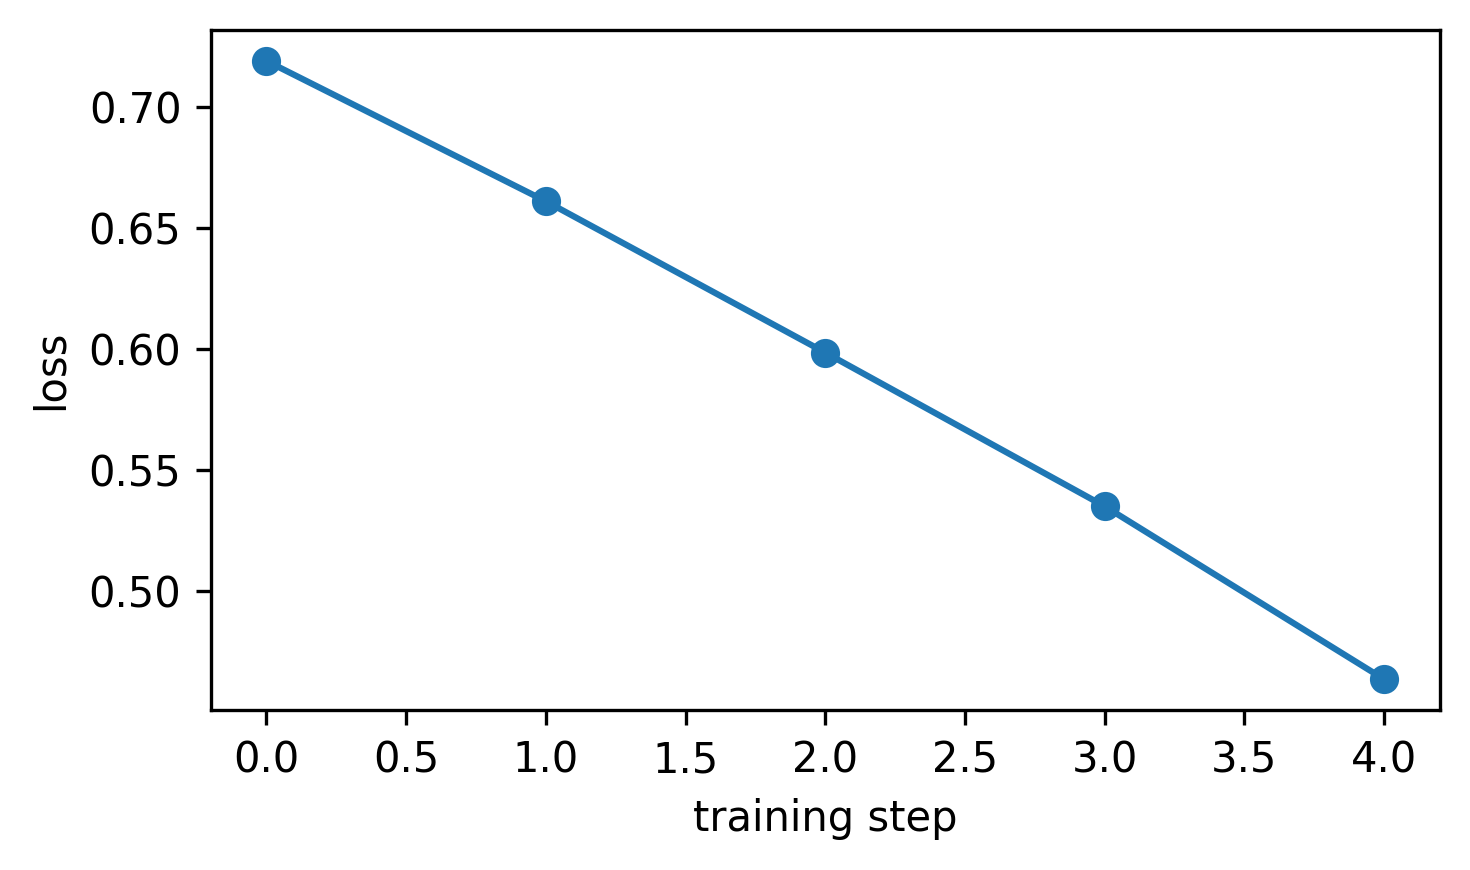

In [5]:
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.dpi": 300, "savefig.dpi": 300})

plt.figure(figsize=(5, 3))
plt.plot(metrics["losses"], marker="o")
plt.xlabel("training step")
plt.ylabel("loss")
plt.tight_layout()

A fully configurable stack is still just JSON. The configuration below chooses
each local branch, global branch, self branch, and solver separately:

$$
z_\ell^\star=f_{\theta_\ell}(z_\ell^\star,h_{\ell-1}),
\qquad
h_\ell=z_\ell^\star.
$$

Layer $\ell$ receives its own $L_\ell$, $G_\ell$, $H_\ell$, and
`SolverConfig`.

In [6]:
config_path = root / "experiments/public/configs/fully_configurable_graph.json"
config = json.loads(config_path.read_text())
config["device"] = "cpu"
metrics = runner.run_config(config)
metrics["output_shape"], metrics["state_shape"], metrics["solver_residuals"]

([3, 2], [18, 10], [3.4871530532836914, 3.587737560272217, 4.515204429626465])

## Citation and Sources

If this notebook or package is used, cite the software repository:

```text
Dr. Jose Luis Silva. SILVA Networks. Version 1.2.0. MIT License.
https://github.com/jseluis/silva-networks
https://doi.org/10.5281/zenodo.21770098
```

When the work is connected to the SILVA Networks paper, cite the paper as well:

```text
Jose Luis Lima de Jesus Silva. SILVA Networks as Structured Implicit Layers and
Vector Attractors via Dynamic Interaction Fields. 2026. arXiv:2607.28989.
https://arxiv.org/abs/2607.28989
```

Background references used in the tutorial suite include:

- Deep Equilibrium Models, Bai, Kolter, and Koltun, NeurIPS 2019:
  https://arxiv.org/abs/1909.01377
- Multiscale Deep Equilibrium Models, Bai, Koltun, and Kolter, NeurIPS 2020:
  https://arxiv.org/abs/2006.08656
- Stabilizing Equilibrium Models by Jacobian Regularization, Bai, Koltun, and
  Kolter, ICML 2021: https://arxiv.org/abs/2106.14342
- Graph Attention Networks, Velickovic et al., ICLR 2018:
  https://arxiv.org/abs/1710.10903
- Attention Is All You Need, Vaswani et al., 2017:
  https://arxiv.org/abs/1706.03762

## From 04 Public Experiments to a Custom SILVA Family

The construction in this notebook can be separated into the universal
conditioned-equilibrium contract

$$
z_0=I_\eta(x),\qquad
z^\star=T_\theta(z^\star,x),\qquad
\widehat y=Q_\psi(z^\star).
$$

For this topic:

| Part | Concrete interpretation |
| --- | --- |
| Equilibrium state | the tensor solved to equilibrium |
| Condition | the observed input or source tensor |
| Repeated computation | the state-preserving transition evaluated by the root solver |
| Required invariants | shape, device, dtype, finiteness, and differentiability |
| Replaceable components | initializer, source encoder, transition, readout, and solver |

The initializer and source path are evaluated outside or alongside the root
solve. Only the state-preserving transition is repeated. Replacing an internal
architecture does not change this equation, provided the transition still maps
the same state space into itself.


In [ ]:
import torch as silva_extension_torch
from torch import nn as silva_extension_nn

from silva_networks import (
    SILVAConditionedEquilibrium,
    SILVAZeroInitializer,
    SolverConfig,
    validate_silva_transition,
)


class NotebookExtensionTransition(silva_extension_nn.Module):
    def __init__(self, condition_dim=2, state_dim=3):
        super().__init__()
        self.source = silva_extension_nn.Linear(condition_dim, state_dim)
        self.state_field = silva_extension_nn.Sequential(
            silva_extension_nn.Linear(state_dim, 2 * state_dim),
            silva_extension_nn.Tanh(),
            silva_extension_nn.Linear(2 * state_dim, state_dim),
        )

    def forward(self, state, condition):
        return silva_extension_torch.tanh(
            self.source(condition) + 0.15 * self.state_field(state)
        )


silva_extension_torch.manual_seed(610)
notebook_condition = silva_extension_torch.linspace(-1.0, 1.0, 8).reshape(4, 2)
notebook_state0 = silva_extension_torch.zeros(4, 3)
notebook_transition = NotebookExtensionTransition()

notebook_report = validate_silva_transition(
    notebook_transition,
    notebook_state0,
    notebook_condition,
)
assert notebook_report.valid

with silva_extension_torch.no_grad():
    notebook_reference_step = silva_extension_torch.tanh(
        notebook_transition.source(notebook_condition)
        + 0.15 * notebook_transition.state_field(notebook_state0)
    )
silva_extension_torch.testing.assert_close(
    notebook_transition(notebook_state0, notebook_condition),
    notebook_reference_step,
)

notebook_custom_model = SILVAConditionedEquilibrium(
    notebook_transition,
    SILVAZeroInitializer(3),
    readout=silva_extension_nn.Linear(3, 1),
    config=SolverConfig(
        solver="picard",
        max_iter=40,
        tol=1e-7,
        backward_mode="implicit",
        backward_solver="gmres",
        anderson_batch_dims=1,
    ),
)
notebook_custom_result = notebook_custom_model(
    notebook_condition,
    return_result=True,
)
assert notebook_custom_result.output.shape == (4, 1)
assert notebook_custom_result.solver_result.residual < 1e-5

notebook_custom_result.output.square().mean().backward()
assert all(
    parameter.grad is not None and silva_extension_torch.isfinite(parameter.grad).all()
    for parameter in notebook_custom_model.parameters()
)
print("custom transition:", notebook_report)
print("equilibrium residual:", notebook_custom_result.solver_result.residual)


## Numerical Equivalence, Compact Reproduction, and Scale

Before training, compare one packaged transition with an independently written
update:

$$
e_{\mathrm{step}}
=\frac{\|T_\theta(z,x)-T_{\mathrm{ref}}(z,x)\|_2}
{\|T_{\mathrm{ref}}(z,x)\|_2+\varepsilon}.
$$

After solving, report the fixed-point residual separately:

$$
e_{\mathrm{fp}}
=\frac{\|T_\theta(z^\star,x)-z^\star\|_2}
{\|z^\star\|_2+\varepsilon}.
$$

For this notebook, a compact reproduction must declare and assert
**fixed-point residual and task error against a deterministic target**. A full experiment must additionally record the
source dataset version and split, preprocessing, architecture widths, solver
and optimizer schedules, random seeds, baseline configuration, checkpoints,
and every deviation from the cited protocol.

The principal scaling axes are **state width, batch size, and data volume**. Increase one axis at
a time, retain the compact deterministic case as a regression test, and record
task error, domain-specific residual, forward residual, backward linear
residual, memory use, and runtime independently.

### Extension Exercises

1. Replace one component from this notebook while preserving its state and
   domain invariants.
2. Write the replacement first as an independent reference function, then as
   a module, and assert one-step equivalence.
3. Compare two solver configurations on the identical trained transition.
4. Add a compact baseline and a predeclared metric threshold.
5. Create a full-scale configuration without weakening the compact tests.

The complete authoring protocol is documented in
[Extending SILVA](https://jseluis.github.io/silva-networks/learn/extending-silva/).


In [ ]:
notebook_reproduction_record = {
    "notebook": '04_public_experiments.ipynb',
    "state": 'the tensor solved to equilibrium',
    "condition": 'the observed input or source tensor',
    "transition": 'the state-preserving transition evaluated by the root solver',
    "invariants": 'shape, device, dtype, finiteness, and differentiability',
    "compact_metric": 'fixed-point residual and task error against a deterministic target',
    "scale_axis": 'state width, batch size, and data volume',
}
assert all(notebook_reproduction_record.values())
notebook_reproduction_record


## Where to Go Next

| Question | Page |
| --- | --- |
| Which experiment configurations are available? | [Public Experiments](https://jseluis.github.io/silva-networks/experiments/) |
| Which measured summaries have been checked? | [Benchmark Cards](https://jseluis.github.io/silva-networks/experiments/benchmark-cards/) |
| Which functions run and override configurations? | [Public Experiments API](https://jseluis.github.io/silva-networks/api/public_experiments/) |
